


**By the end of this class, you will be able to:**
- Explain what Seaborn is and why it exists
- Explain how Seaborn compares to Matplotlib and how it works with Pandas
- Load a dataset with Seaborn and inspect it with Pandas
- Create the most common Seaborn plots: scatter, line, bar, count, histogram, box, heatmap
- Use `x`, `y`, `data`, and `hue` to control what a plot shows
- Apply basic customization (titles, labels, themes)
- Visualize relationships, distributions, and categories in real data

We will use ONE dataset for the whole class — Seaborn's built-in `tips` dataset — so you
never have to context-switch to a new dataset while learning a new plot.




**What it is:** Seaborn is a Python library for making statistical charts. It is built
directly on top of Matplotlib — every Seaborn plot is secretly a Matplotlib plot underneath.

**Why it's used:** Plain Matplotlib is powerful but low-level — you often need many lines
of code just to color points by a category or add a trend line. Seaborn gives you that kind
of statistical chart in a single function call, and it understands Pandas DataFrames
natively, so you can plot straight from your columns by name instead of pulling out raw
arrays first.

**How the three tools relate:**

| Tool | Role |
|---|---|
| **Pandas** | Loads and organizes your data (DataFrames) |
| **Seaborn** | Turns a DataFrame into a statistical chart, quickly |
| **Matplotlib** | The underlying engine — Seaborn uses it, and you can still use it directly to fine-tune anything Seaborn draws |

A useful way to remember it: **Pandas → handles the data, Seaborn → makes the statistical
plot easy, Matplotlib → gives you full control when you need it.**

Let's import both libraries. By convention, Seaborn is always imported as `sns` (named
after a character from The West Wing — it's just tradition, nothing to memorize).

In [ ]:
# Seaborn is conventionally imported as sns
import seaborn as sns

# We still need Matplotlib to actually display the plots
import matplotlib.pyplot as plt

print("Seaborn version:", sns.__version__)

Seaborn version: 0.13.2


## 3. Load the Dataset

**Why we start here:** every Seaborn plot needs a DataFrame to plot from. Before drawing
anything, we should always look at the data first — what columns exist, what type each
one is, and whether anything looks unusual.

Seaborn ships with a few small practice datasets built in, so there's nothing to download
by hand. We'll use `tips`: real (anonymized) restaurant bills, each row is one table's visit.

In [ ]:
# Load the built-in "tips" dataset as a Pandas DataFrame
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# How many rows and columns do we have?
df.shape

(244, 7)

In [ ]:
# What are the column names?
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [ ]:
# Data types and non-null counts for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
# Quick statistical summary of the numeric columns
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**What each column means:**

| Column | Meaning |
|---|---|
| `total_bill` | Total cost of the meal, in dollars |
| `tip` | Tip amount, in dollars |
| `sex` | Sex of the person who paid the bill |
| `smoker` | Whether anyone in the party was a smoker (Yes/No) |
| `day` | Day of the week |
| `time` | Lunch or Dinner |
| `size` | Number of people at the table |

### 💡 Exercise 1

Looking at the table above, write down:
1. Which columns are **numerical** (measured as numbers)?
2. Which columns are **categorical** (a label / group)?

Just think it through or jot it in the empty cell below — no code needed yet.

In [ ]:
# Exercise 1 — jot your answer here (as a comment or a plain string)




<details>
<summary>▶ Click to reveal the answer (teacher: reveal after discussion)</summary>

**Numerical columns:** `total_bill`, `tip`, `size`
*(size is technically a count, but Pandas treats it as a number — we'll mostly use it as one.)*

**Categorical columns:** `sex`, `smoker`, `day`, `time`

A quick rule of thumb: if you could sensibly take an *average* of a column, it's numerical.
You can't average "Sunday" and "Male" — so those are categorical.
</details>

## 4. Your First Seaborn Plot

**Why start with a scatter plot:** it's the simplest possible chart — one dot per row of
data — and it immediately shows us whether two numbers are related. Here we'll check:
does a bigger total bill mean a bigger tip?

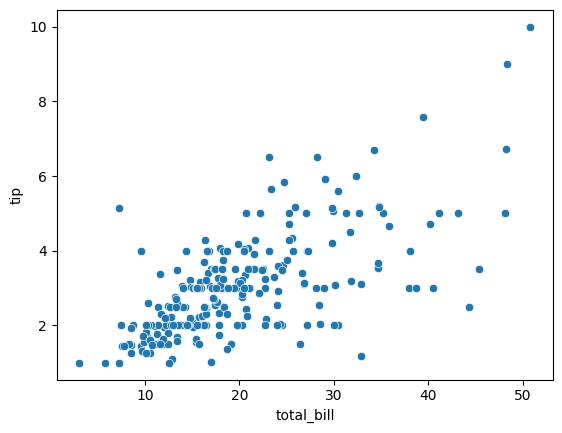

In [ ]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.show()

**Breaking down that one line:**

- `sns.scatterplot(...)` — the Seaborn function that draws a scatter plot
- `data=df` — tells Seaborn which DataFrame to pull columns from
- `x="total_bill"` — which column goes on the horizontal axis
- `y="tip"` — which column goes on the vertical axis

**What the plot tells us:** each dot is one restaurant visit. As `total_bill` increases
(moving right), `tip` tends to increase too (moving up) — the dots drift upward left-to-right,
so bigger bills generally get bigger tips.

**Why this is convenient compared to plain Matplotlib:** in Matplotlib you'd have to pull
the columns out yourself first —

```python
plt.scatter(df["total_bill"], df["tip"])
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()
```

That's not much extra work for a plain scatter plot, but as we add color grouping in the
next section, the gap between the two grows a lot. That's the whole value of Seaborn:
DataFrame columns in, statistical chart out.

## 5. Scatter Plot with `hue`  

**Why we need this:** the plot above shows the relationship between bill and tip, but it
mixes everyone together. What if we want to see whether that relationship differs between,
say, men and women? We need a way to color points by a category — that's what `hue` is for.

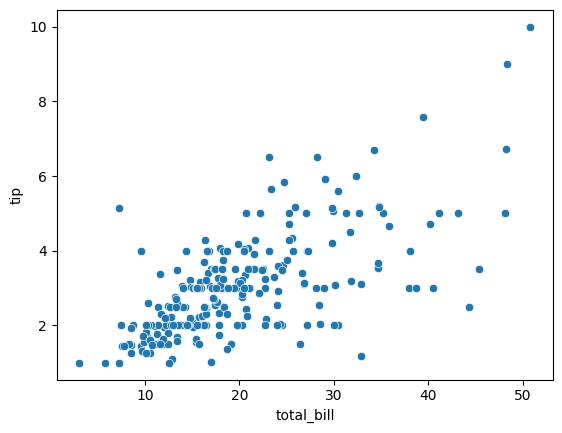

In [ ]:
# Same scatter plot as before, plotted plain first
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.show()

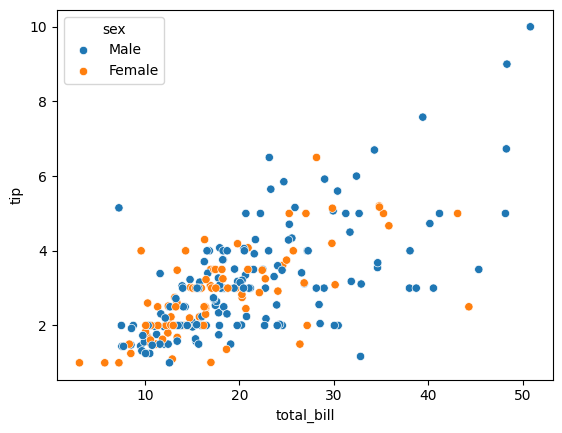

In [ ]:
# Now add hue to color the points by sex
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex"
)
plt.show()

**`hue` means: use color to represent another variable.** Seaborn automatically picks a
color for each category in that column and adds a legend — we didn't have to do either by hand.

Let's try a different category — `smoker` — on the exact same x and y:

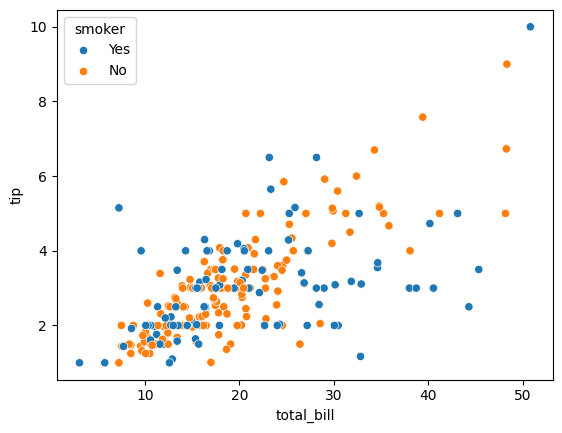

In [ ]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="smoker"
)
plt.show()

### 💡 Exercise 2

Make a scatter plot of `total_bill` vs `tip`, but color the points by `day` instead.
Write your code in the cell below.

In [ ]:
# Exercise 2 — your code here



<details>
<summary>▶ Click to reveal the answer</summary>

```python
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="day"
)
plt.show()
```
</details>

## 6. Line Plot

**Why used:** line plots are best when you want to show a **trend** — how one value changes
as another one increases in order (like time, or table size). They're less useful for data
like ours where the x-axis isn't naturally ordered/continuous, but it's worth seeing what
happens with `size` (number of people at the table) vs average `tip`.

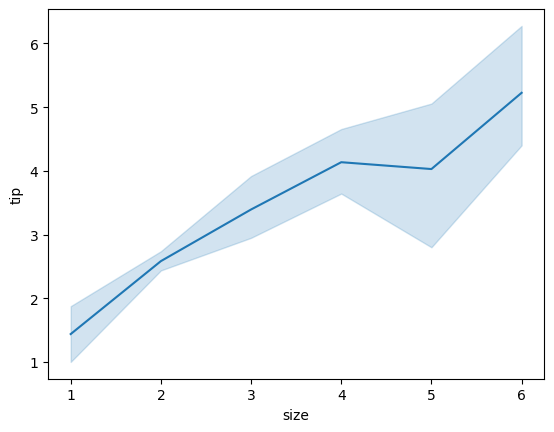

In [ ]:
sns.lineplot(data=df, x="size", y="tip")
plt.show()

Seaborn's line plot automatically averages `tip` for every table `size` and even shades a
confidence interval around the line (that light shaded band) — showing how much the tip
amount varies at each size, not just its average. We won't go deeper into that shading today,
just know it's telling you "how much the values at this point actually varied."


## 7. Bar Plot  

**Why used:** bar plots compare a numerical value **across categories** — here, the average
total bill on each day of the week. This is different from the scatter plot: instead of every
individual point, we get one summary bar per category.

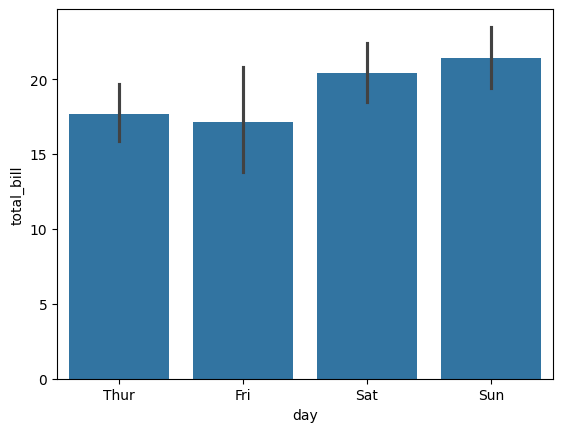

In [ ]:
sns.barplot(data=df, x="day", y="total_bill")
plt.show()

**What's happening:**
- `x="day"` — a **categorical** column (Thu/Fri/Sat/Sun), one bar per category
- `y="total_bill"` — a **numerical** column
- Each bar's height is the **average** `total_bill` for that day
- The thin black line at the top of each bar is a confidence interval, similar to the line plot

Now let's split each day's bar by `sex` using `hue`, same idea as before:

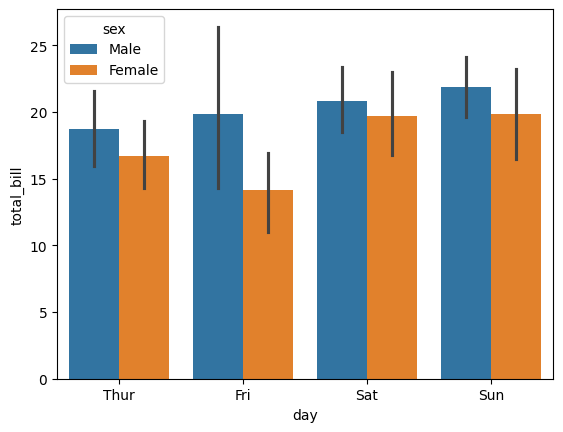

In [ ]:
sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    hue="sex"
)
plt.show()

**`barplot` vs `countplot` — don't confuse them:**
`barplot` shows the **average of a numerical column** for each category (needs both `x` and `y`).
The next section, `countplot`, instead shows **how many rows** fall into each category
(needs only one column) — no averaging involved.

## 8. Count Plot  
**Why used:** sometimes we don't want an average of anything — we just want to know
**how many rows exist for each category**. "How many tables did we serve on each day?"
is a counting question, not an averaging question, so this needs a different function.

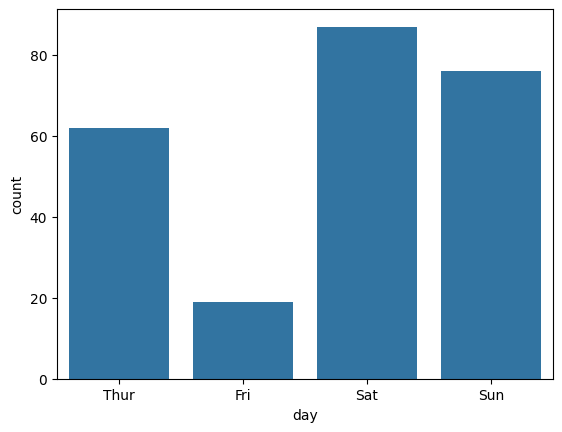

In [ ]:
sns.countplot(data=df, x="day")
plt.show()

**`countplot` counts how many observations belong to each category.** Notice we only gave
it `x="day"` — no `y` at all, because Seaborn is doing the counting for us.

Just like before, we can split each bar by another category with `hue`:

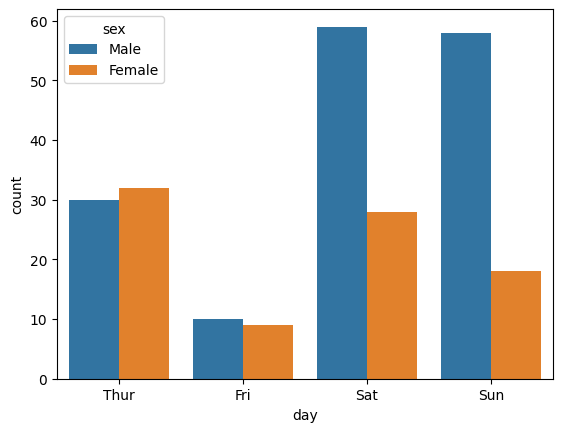

In [ ]:
sns.countplot(
    data=df,
    x="day",
    hue="sex"
)
plt.show()

### 💡 Exercise 3

Make a count plot of `time` (Lunch vs Dinner), split by `smoker` using `hue`.

In [ ]:
# Exercise 3 — your code here



<details>
<summary>▶ Click to reveal the answer</summary>

```python
sns.countplot(
    data=df,
    x="time",
    hue="smoker"
)
plt.show()
```
</details>

## 9. Histogram

**Why used:** a histogram shows the **distribution** of a single numerical column — not
comparing categories, but seeing the overall shape of the data. Are most bills small?
Are there a few huge outlier bills? A histogram answers that at a glance.

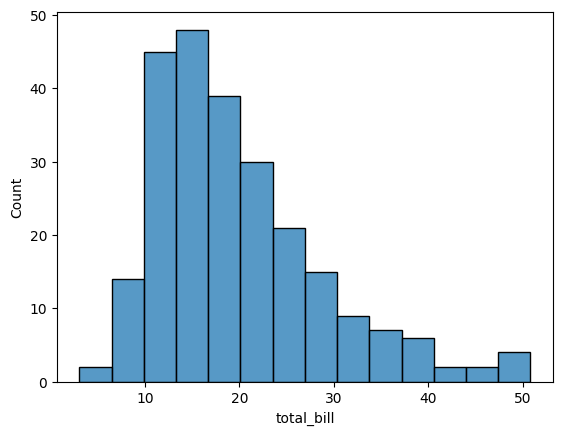

In [ ]:
sns.histplot(data=df, x="total_bill")
plt.show()

**Key ideas:**
- The x-axis is split into ranges called **bins** (e.g. \$10–15, \$15–20, ...)
- The height of each bar is the **frequency** — how many bills fall in that range
- This is our whole `total_bill` column's **distribution** in one picture: most bills cluster
  in a certain range, with fewer very small or very large ones

Seaborn can also draw a smooth curve over the bars called a **KDE** (kernel density estimate)
— think of it as a smoothed-out version of the histogram's shape, useful for seeing the
overall trend without being distracted by individual bin heights. We won't go into the maths
behind it today.

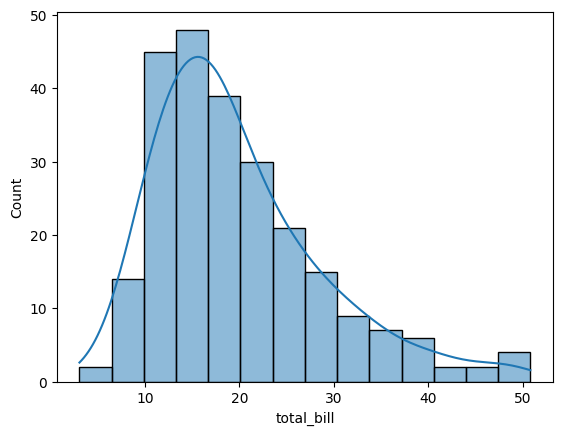

In [ ]:
sns.histplot(
    data=df,
    x="total_bill",
    kde=True
)
plt.show()

## 11. Heatmap and Correlation  

**Why used (brief intro only):** sometimes we want to see how EVERY numerical column relates
to every other numerical column, all at once. A **correlation** is a number between -1 and 1
that tells us how strongly two columns move together. A **heatmap** lets us see a whole grid
of correlations as colors instead of reading a table of numbers.

- **Positive correlation** (close to +1): as one column goes up, the other tends to go up too
- **Negative correlation** (close to -1): as one column goes up, the other tends to go down
- **Close to 0**: little to no relationship

We won't cover the math behind how correlation is calculated today — just how to read it.

In [ ]:
# Keep only the numerical columns, then compute correlation between every pair
corr = df.select_dtypes("number").corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


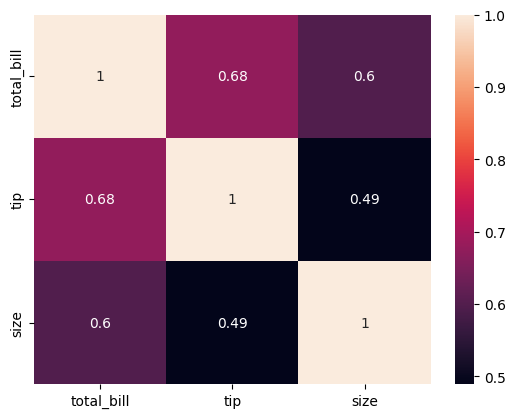

In [ ]:
sns.heatmap(corr, annot=True)
plt.show()

**`annot=True`** prints the actual correlation number inside each square, instead of
leaving us to guess from color alone. Notice `total_bill` and `tip` have a strong positive
correlation — matching what we already saw in our very first scatter plot at the start
of class.

## 12. Basic Customization

**Why used:** Seaborn draws the statistical chart, but it's still a Matplotlib plot
underneath — so ordinary Matplotlib commands like `plt.title()` still work on top of it.
This is the payoff of Seaborn being "built on" Matplotlib rather than replacing it.

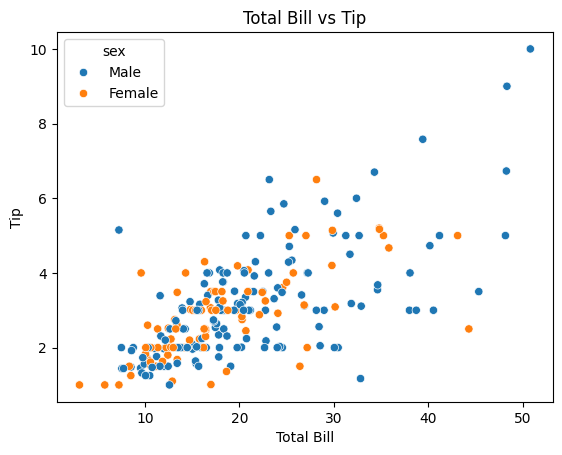

In [ ]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex"
)

# These are plain Matplotlib commands, working on top of the Seaborn plot
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

Seaborn also has its own way to change the overall *look* of every plot at once, using a
**theme**. Run the cell below, then scroll back up and imagine every earlier plot with a
light grid behind it — that's what this line changes, for every plot from now on.

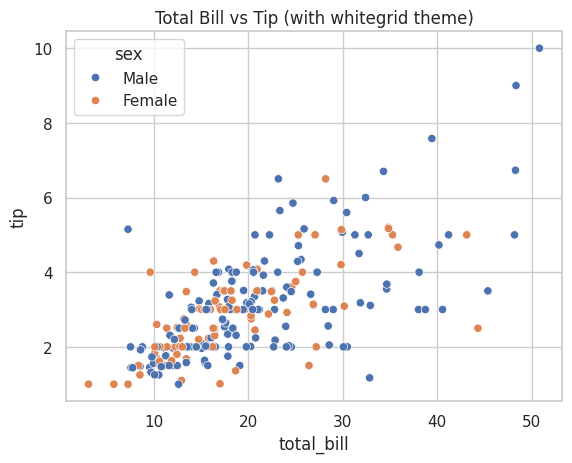

In [ ]:
sns.set_theme(style="whitegrid")

# Re-draw the same scatter plot to see the new theme applied
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.title("Total Bill vs Tip (with whitegrid theme)")
plt.show()

**In short:** `sns.set_theme()` controls the overall visual style (background, grid,
color palette) for every plot in the notebook, while individual Matplotlib commands like
`plt.title()` still customize one plot at a time.

## 13. Important Seaborn Parameters

A quick reference for the parameters you've now used in almost every plot today:

| Parameter | Meaning |
|---|---|
| `data=` | Which DataFrame to plot from |
| `x=` | Column for the horizontal axis |
| `y=` | Column for the vertical axis |
| `hue=` | Column to use for **color** grouping |
| `style=` | Column to use for **marker shape/line style** grouping |
| `size=` | Column to use for **point/line size** grouping |

We've used `hue` heavily today because it's the most common one. `style` and `size` follow
the exact same idea — just controlling shape or size instead of color. A quick look, not
worth spending much class time on:

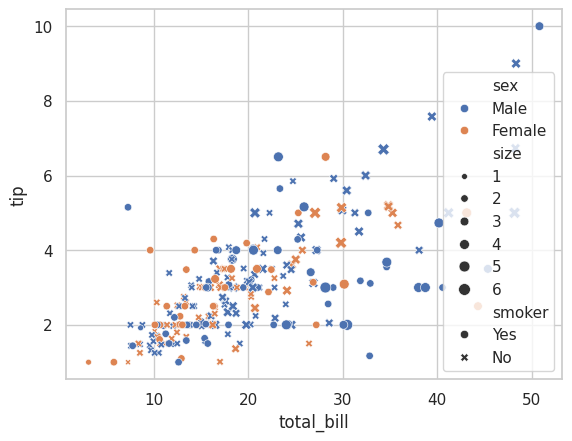

In [ ]:
# style changes marker shape per category, size changes marker size per category
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker",
    size="size"
)
plt.show()

## 14. Mini Practice Project
Using the same `df` (tips dataset), complete the seven tasks below. Try each one yourself
in the empty code cell before revealing the answer underneath it.


**Task 1 — Scatter plot of `total_bill` vs `tip`.**

In [ ]:
# Task 1 — your code here



<details><summary>▶ Reveal answer</summary>

```python
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.show()
```
</details>

**Task 2 — Same scatter plot, but use `hue` to separate smokers from non-smokers.**

In [ ]:
# Task 2 — your code here



<details><summary>▶ Reveal answer</summary>

```python
sns.scatterplot(data=df, x="total_bill", y="tip", hue="smoker")
plt.show()
```
</details>

**Task 3 — Count plot of `day`.**

In [ ]:
# Task 3 — your code here



<details><summary>▶ Reveal answer</summary>

```python
sns.countplot(data=df, x="day")
plt.show()
```
</details>

**Task 4 — Bar plot of average `total_bill` by `day`.**

In [ ]:
# Task 4 — your code here



<details><summary>▶ Reveal answer</summary>

```python
sns.barplot(data=df, x="day", y="total_bill")
plt.show()
```
</details>

**Task 5 — Histogram of `total_bill`.**

In [ ]:
# Task 5 — your code here



<details><summary>▶ Reveal answer</summary>

```python
sns.histplot(data=df, x="total_bill")
plt.show()
```
</details>

**Task 6 — Box plot of `total_bill` by `day`.**

In [ ]:
# Task 6 — your code here



<details><summary>▶ Reveal answer</summary>

```python
sns.boxplot(data=df, x="day", y="total_bill")
plt.show()
```
</details>

**Task 7 — Heatmap of the numerical correlations.**

In [ ]:
# Task 7 — your code here



<details><summary>▶ Reveal answer</summary>

```python
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, annot=True)
plt.show()
```
</details>

## 15. Final Cheat Sheet  *(~1 min)*

| Purpose | Seaborn Function |
|---|---|
| Relationship between two numbers | `scatterplot()` |
| Trend across an ordered value | `lineplot()` |
| Compare a number across categories | `barplot()` |
| Count rows per category | `countplot()` |
| Distribution of one number | `histplot()` |
| Spread / outliers per category | `boxplot()` |
| Correlation between numbers | `heatmap()` |

**The basic syntax pattern behind almost every plot today:**

```python
sns.plot_function(
    data=df,
    x="column",
    y="column",
    hue="column"
)
```


## 16. Final Summary

- **Seaborn** is built on Matplotlib and makes statistical charts from a Pandas DataFrame in one function call
- Almost every plot follows the same pattern: `sns.plot_function(data=df, x=..., y=..., hue=...)`
- **`hue`** colors points/bars by a category — the single most useful parameter you learned today
- **scatterplot** and **lineplot** show relationships and trends between two numbers
- **barplot** and **countplot** compare categories — averages vs. raw counts, don't mix them up
- **histplot** and **boxplot** describe a single column's distribution and spread
- **heatmap** shows correlation between every pair of numerical columns at once
- Seaborn still lets you use plain Matplotlib (`plt.title()`, etc.) on top of any plot, and `sns.set_theme()` changes the overall look for every plot at once

**Next steps beyond this class** (not covered today): `pairplot()`, `violinplot()`,
`FacetGrid`, regression plots, and deeper statistical customization.